- The outcome variable is `time until an event occurs`
- Person/subject might drop from study or study has concluded but event did not occur for the subject, this is called `censored` data
- Survival analysis is not just limited to medical studies but has been used in `churn` model (customer cancels subscription/service etc.).
  Model person's weight using some covariates but weighing scale can weight person upto 100kg.
- Notation, T = Survival/Failure/Event Time, C = Censored Time
- We observe either T or C i.e.
  $Y = \min(T, C)$

- Status indicator \begin{equation} \delta =  \begin{cases} 
      1 &  T\leq C \\
      0 &  T > C
   \end{cases}
\end{equation}
$\delta$ = 1, if we observe true survival time and it is 0 if observed censoring time.
We observe n (Y, $\delta$) pairs i.e. $(y_1, \delta_1)$, $(y_2, \delta_2)$, ..., $(y_n, \delta_n)$


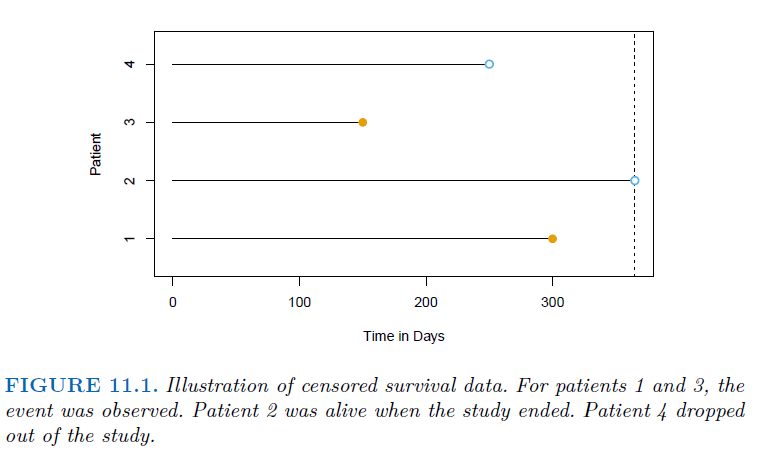   

- We assume that `censoring mechanism is independent` i.e. conditional on the features, the event time T is independent of the censoring time C.
- `Right censoring` occurs when T $\geq$ Y i.e. the true event time T is at least as large as the observed time Y. In `left censoring`, the true event time T is less than or equal to the observed
time Y .

## The Kaplan–Meier Survival Curve  
The survival curve, or survival function, is defined as   
$S(t) = Pr(T > t)$

In [2]:
from ISLP import load_data

In [5]:
brain_cancer = load_data('BrainCancer')
brain_cancer.columns

Index(['sex', 'diagnosis', 'loc', 'ki', 'gtv', 'stereo', 'status', 'time'], dtype='object')

In [6]:
brain_cancer

,sex,diagnosis,loc,ki,gtv,stereo,status,time
0,Female,Meningioma,Infratentorial,90,6.11,SRS,0,57.64
1,Male,HG glioma,Supratentorial,90,19.35,SRT,1,8.98
2,Female,Meningioma,Infratentorial,70,7.95,SRS,0,26.46
3,Female,LG glioma,Supratentorial,80,7.61,SRT,1,47.80
4,Male,HG glioma,Supratentorial,90,5.06,SRT,1,6.30
...,...,...,...,...,...,...,...,...
83,Male,HG glioma,Supratentorial,80,0.16,SRT,1,20.69
84,Male,HG glioma,Supratentorial,80,19.81,SRT,1,6.39
85,Male,Meningioma,Supratentorial,90,2.50,SRT,0,32.82
86,Male,Meningioma,Supratentorial,90,2.02,SRS,0,42.07


let $d_1 < d_2 < · · · < d_K$ denote the K unique death times among the noncensored
patients, and we let $q_k$ denote the number of patients who died at time $d_k$. For k = 1, . . . ,K, we let $r_k$ denote the number of patients alive 
and in the study just before $d_k$; these are the at risk patients. The set of patients that are at risk at a given time are referred to as the risk set.  
$ Pr(T > d_k) =Pr(T > d_k|T > d_{k−1}) Pr(T > d_{k−1}) + Pr(T > d_k|T \leq d_{k−1}) Pr(T \leq d_{k−1}) $.   
$ S(d_k) = Pr(T > d_k) =Pr(T > d_k|T > d_{k−1}) Pr(T > d_{k−1})$ .    
$ S(d_k) = Pr(T > d_k|T > d_{k−1}) S(d_{k-1})$ .     
$ S(d_k) = Pr(T > d_k|T > d_{k−1}) × · · · × Pr(T > d_2 |T > d_1 ) Pr(T > d_1)$ .    
using the estimates   $\hat{Pr}(T > d_j |T > d_{j−1}) = (r_j − q_j)/r_j$    
This leads to the Kaplan–Meier estimator of the survival curve   
$ \hat{S}(d_k) =\prod_{j=1}^{K} \frac{r_j-q_j}{q_j}$    
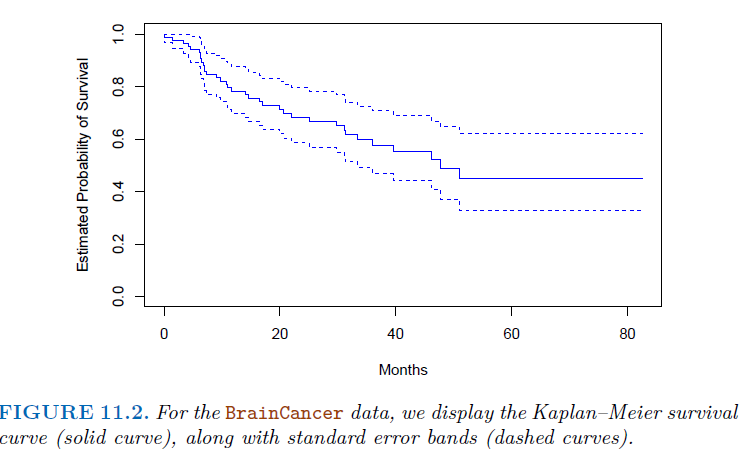

## The log rank test  
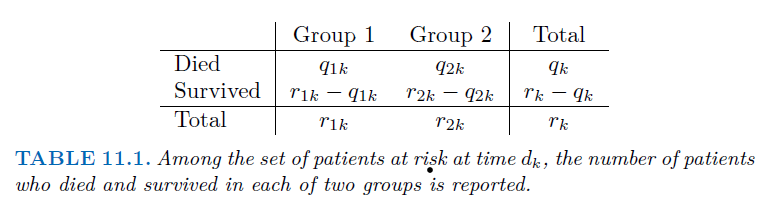  


At each death time $d_k$, we construct a 2 × 2 table of counts of the form shown  

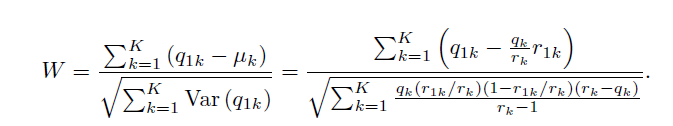   

$H_0:$ There is no difference in survival between the two groups   
When the sample size is large, the log-rank test statistic W has approximately
a standard normal distribution